# LA PRUEBA T (T-TEST) DE UNA MUESTRA (BILATERAL)

En este ejemplo práctico abordaremos el mismo problema de la lección 4 (cuando hablamos de la prueba z de una muestra) pero en este caso haciendo uso de la prueba t:

> Supongamos que somos científicos de datos y desarrollamos un modelo de Machine Learning para apoyo diagnóstico de enfermedades cardiacas. El modelo tiene un desempeño promedio (F1-score) de 0.86 ~~y una desviación estándar de 0.03~~ y estos parámetros se han obtenido tras aplicar pruebas durante los últimos dos años en varios miles de pacientes. **Ahora hemos hecho modificaciones al modelo y queremos asegurarnos de que su desempeño no ha cambiado**

## 1. Desarrollo de la prueba de hipótesis (t-test de una muestra bilateral)

En este caso se trata de una prueba bilateral porque el nuevo modelo podría generar un **incremento o reducción** del desempeño, pero queremos asegurarnos que desde el punto de vista estadístico en esencia el desempeño es el mismo del modelo original.

> **Aspecto importante a tener en cuenta**: en este caso debemos tener una estimación de la media de la población (F1-score de 0.86) pero **NO es necesario conocer la desviación estándar de dicha población**.

### 1.1. Paso 1: definir el problema del negocio

> **Hemos hecho modificaciones al modelo y queremos asegurarnos de que su desempeño no ha cambiado**

### 1.2. Paso 2: redactar el problema del negocio como un problema de Ciencia de Datos/Machine Learning

> ¿El nuevo modelo tiene un desempeño equivalente, desde el punto de vista estadístico, al modelo original?**

### 1.3. Paso 3: definir $H_0$ y $H_1$

- $H_0$: el promedio de desempeño del nuevo modelo es igual al del modelo anterior $\rightarrow \bar{x} = \mu$
- $H_1$: el promedio de desempeño del nuevo modelo es **diferente** que el del modelo anterior $\rightarrow \bar{x} \neq \mu$ 

*Nota: recordemos que $\mu = 0.86$*

### 1.4. Paso 4: definir $\alpha$

Asumiremos un nivel de significancia $\alpha = 0.05$ y, por ser una prueba bilateral, este nivel estará dividido equitativamente entre las dos colas de la distribución.

Aún no dibujaremos esta distribución pues en este caso se requiere el número de datos y aún no hemos llegado a este punto.

### 1.5. Definir la potencia de la prueba ($1-\beta$) y el tamaño de la muestra ($n$)

Comencemos definiendo el tamaño del efecto ($d$) que en este caso se define de forma similar a como lo hicimos en la prueba z:

- 0.2: efecto "pequeño"
- 0.5: efecto "mediano"
- 0.8: efecto "grande"

Aunque esperamos que no cambie el desempeño del modelo, supondremos un tamaño del efecto "mediano" a "grande" en caso de que este exista. Supongamos $d=0.6$.

Además, supondremos una potencia de la prueba de 0.9.

Con estos dos valores ya podemos usar "statsmodels" para calcular el tamaño de la muestra requerido. Para ello usamos el módulo "TTestPower", **especialmente diseñado para t-test de una muestra**:

In [1]:
from statsmodels.stats.power import TTestPower

d = 0.6 # Tamaño del efecto
potencia = 0.9
alpha = 0.05

# Instancia de TTestPower
analisis = TTestPower()

# Cálculo del tamaño de la muestra
n = analisis.solve_power(
    effect_size = d,
    power = potencia,
    alpha = alpha,
    alternative = 'two-sided', # Porque es una prueba bilateral
)
print(f"Tamaño de la muestra: {n}")

Tamaño de la muestra: 31.17168322107312


Es decir que para un tamaño del efecto (si este existe) de 0.6 y una potencia de la prueba de 0.9 requerimos al menos 31 datos.

### 1.6. Paso 6: recolectar y preparar los datos

Supondremos que hemos recolectado $n=100$ datos (los mismos usados en la lección 4) de desempeño del nuevo modelo. A continuación podemos ver estos desempeños:

In [2]:
import pandas as pd

datos = pd.read_csv('dataset_ztest_bilateral.csv')
datos

,f1_score
0,0.812431
1,0.874920
2,0.853489
3,0.799811
4,0.827642
...,...
95,0.875933
96,0.812463
97,0.804096
98,0.856382


Calculemos y almacenemos la media, la desviación estándar y el tamaño de la muestra que serán requeridos para la prueba t:

In [3]:
import numpy as np

x = np.mean(datos['f1_score'])
s = np.std(datos['f1_score'])
n = len(datos)

print(f"Media muestral (x): {x}")
print(f"Desviación estándar muestral (s): {s}")
print(f"Tamaño de la muestra (n): {n}")

Media muestral (x): 0.8458132722047107
Desviación estándar muestral (s): 0.03384721411433883
Tamaño de la muestra (n): 100


Y verifiquemos la normalidad de la muestra (sugerencia: completar lo anterior por ejemplo con gráficos Q-Q):

In [4]:
from scipy.stats import shapiro

W, p_shapiro = shapiro(datos['f1_score'])
p_shapiro

0.2748704400205805

Como p>0.05 no rechazamos la hipótesis nula y por tanto los tienen una distribución normal.

### 1.7. Paso 7: aplicar la prueba estadística para obtener el valor p

Hagamos el análisis manual (opcional) y luego veremos cómo hacerlo usando Scipy.

Comencemos calculando la estadística $t$:

$$t = \frac{\bar{x}-\mu}{s/\sqrt{n}}=\frac{0.845-0.86}{0.03384/\sqrt{100}}=-4.19$$

Y ahora hagamos uso de Python para dibujar la distribución, las zonas de rechazo y la ubicación de este valor de t:


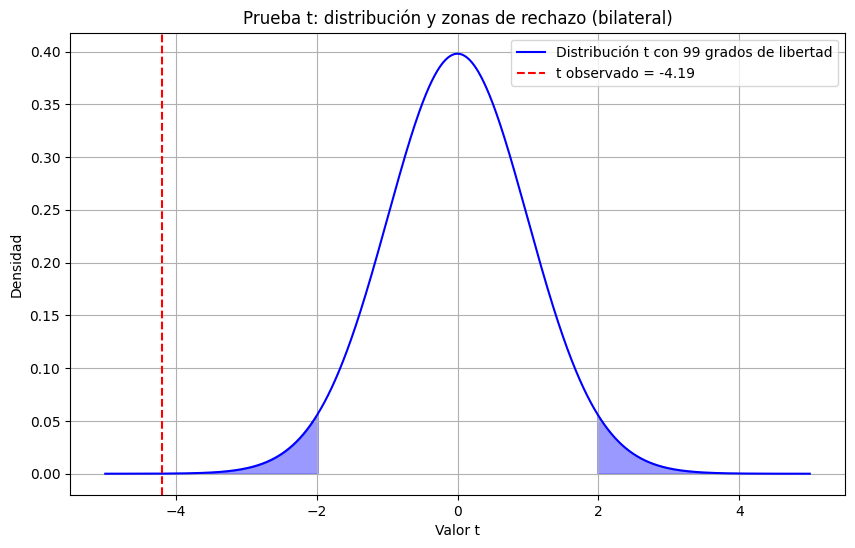

In [5]:
import matplotlib.pyplot as plt
from scipy.stats import t # La distribución t
import numpy as np

# Parámetros
alpha = 0.05
df = n - 1 # Grados de libertad (99)

# Rango de valores t y PDF
t_vals = np.linspace(-5, 5, 1000)
pdf_vals = t.pdf(t_vals, df) # Distribución t para "df" grados de libertad

# Puntos críticos para alfa bilateral derecha
t_critico_der = t.ppf(1 - alpha/2, df) # Zona de rechazo derecha ASUMIENDO DISTRIBUCIÓN CON "df" GRADOS DE LIBERTAD
t_critico_izq = t.ppf(alpha/2, df) # Zona de rechazo izquierda ASUMIENDO DISTRIBUCIÓN CON "df" GRADOS DE LIBERTAD

# Graficar la distribución
plt.figure(figsize=(10, 6))
plt.plot(t_vals, pdf_vals, label=f"Distribución t con {df} grados de libertad", color='blue')

# Zonas de rechazo izquierda y derecha
t_rechazo_der = np.linspace(t_critico_der, 5, 100) # Irá desde t_critico_der hasta 5, 100 datos
t_rechazo_izq = np.linspace(-5, t_critico_izq, 100) # Irá desde t=-5 hasta t_critico_izq, 100 datos
plt.fill_between(t_rechazo_der, t.pdf(t_rechazo_der, df), color='blue', alpha=0.4)
plt.fill_between(t_rechazo_izq, t.pdf(t_rechazo_izq, df), color='blue', alpha=0.4)

# Calcular la estadística de esta prueba
tval = (x-0.86)/(s/np.sqrt(n))

# Y dibujar esta estadística en la distribución anterior
plt.axvline(tval, color='red', linestyle='--', label=f't observado = {tval:.2f}')

# Etiquetas
plt.title('Prueba t: distribución y zonas de rechazo (bilateral)')
plt.xlabel('Valor t')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)


Vemos que el desempeño obtenido se encuentra en la zona de rechazo izquierda y por tanto rechazaríamos la hipótesis nula.

Pero recordemos que este método gráfico es opcional y que podemos simplemente usar Python para calcular esta prueba. En este caso sugiero la librería "pingouin" que condensa en una función todos los tipos de prueba t:

In [9]:
from pingouin import ttest

resultado = ttest(
    x = datos['f1_score'].values, # la muestra
    y = 0.86, # la media poblacional (mu)
    paired = 'False', # NO será una prueba pareada
    alternative = 'two-sided', # Bilateral
    )
resultado

/Users/miguel/.pyenv/versions/academy/lib/python3.11/site-packages/pingouin/parametric.py:228: UserWarning: x and y have unequal sizes. Switching to paired == False. Check your data.
  warnings.warn("x and y have unequal sizes. Switching to paired == False. Check your data.")


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-4.170392,99,two-sided,0.000065,"[0.84, 0.85]",0.417039,273.301,0.984983


Es una función práctica porque además de arrojar como resultado la estadística t y el valor p, también arroja por ejemplo el tamaño del efecto y la potencia de la prueba.

De momento veamos el valor de la estadística t y el valor p:

In [10]:
print(f"Estadística t: {resultado['T'].values[0]}")
print(f"Valor p: {resultado['p-val'].values[0]}")

Estadística t: -4.170392246251157
Valor p: 6.527628532084887e-05


### 1.8. Paso 8: aceptar o rechazar $H_0$

Y vemos que $p = 6.52x10^{-5} <0.05$ y por tanto rechazamos la hipótesis nula (medias iguales) y nos inclinamos por $H_1$ (medias diferentes).

Y por tanto:

> El nuevo modelo no tiene el mismo desempeño del modelo anterior y de hecho hay una reducción en el desempeño (0.86 vs. 0.845)

El resultado es similar al obtenido con la prueba z (lección 4) pero lo importante en este caso es que **esta prueba t no parte del supuesto de que conocemos la desviación estándar de la población**

### 1.9. Paso 9: evaluar el tamaño del efecto y la potencia de la prueba actualizadas

Estos valores ya fueron calculados previamente con ayuda de Pingouin:

In [11]:
print(f"Tamaño del efecto actualizado: {resultado['cohen-d'].values[0]}")
print(f"Potencia de la prueba actualizada: {resultado['power'].values[0]}")

Tamaño del efecto actualizado: 0.41703922462511567
Potencia de la prueba actualizada: 0.9849832317322561


Esto quiere decir que:

> Encontramos un efecto moderado (d ≈ 0.42) y una alta potencia (98.5%) así que podemos concluir que, si hubiera una diferencia relevante, la prueba tendría muchas probabilidades de detectarla

Y en esencia esto nos permite concluir que **el nuevo modelo empeora el desempeño de las predicciones en comparación con el modelo anterior👎👎👎**